<a href="https://colab.research.google.com/github/sodairahmad/AI-ML-Classification-/blob/main/Random_Forest%2C_GB%2C_DT_Ml_Algorithm_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Clone roop repo and install dependencies

In [ ]:
!git clone https://github.com/s0md3v/roop.git
%cd roop
!pip install -r requirements.txt

Cloning into 'roop'...
remote: Enumerating objects: 1528, done.
remote: Counting objects: 100% (563/563), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 1528 (delta 496), reused 463 (delta 442), pack-reused 965
Receiving objects: 100% (1528/1528), 97.42 MiB | 38.59 MiB/s, done.
Resolving deltas: 100% (916/916), done.
/content/roop
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118
Ignoring tkinterdnd2-universal: markers 'sys_platform == "darwin" and platform_machine == "arm64"' don't match your environment
Ignoring onnxruntime: markers 'python_version != "3.9" and sys_platform == "darwin" and platform_machine != "arm64"' don't match your environment
Ignoring onnxruntime-coreml: markers 'python_version == "3.9" and sys_platform == "darwin" and platform_machine != "arm64"' don't match your environment
Ignoring onnxruntime-silicon: markers 'sys_platform == "darwin" and platform_machine == "arm64"' don't match your environment
     ━

#download model

In [ ]:
!wget https://huggingface.co/ezioruan/inswapper_128.onnx/resolve/main/inswapper_128.onnx -O inswapper_128.onnx
!mkdir models
!mv inswapper_128.onnx ./models

--2023-08-27 05:12:18--  https://huggingface.co/ezioruan/inswapper_128.onnx/resolve/main/inswapper_128.onnx
Resolving huggingface.co (huggingface.co)... 18.172.134.24, 18.172.134.124, 18.172.134.4, ...
Connecting to huggingface.co (huggingface.co)|18.172.134.24|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs.huggingface.co/repos/40/3c/403ce23d3f5c02a28fcbe749205d5c8245b2812e6c948bae7abac24495779bc7/e4a3f08c753cb72d04e10aa0f7dbe3deebbf39567d4ead6dce08e98aa49e16af?response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27inswapper_128.onnx%3B+filename%3D%22inswapper_128.onnx%22%3B&Expires=1693369229&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTY5MzM2OTIyOX19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5odWdnaW5nZmFjZS5jby9yZXBvcy80MC8zYy80MDNjZTIzZDNmNWMwMmEyOGZjYmU3NDkyMDVkNWM4MjQ1YjI4MTJlNmM5NDhiYWU3YWJhYzI0NDk1Nzc5YmM3L2U0YTNmMDhjNzUzY2I3MmQwNGUxMGFhMGY3ZGJlM2RlZWJiZjM5NTY3ZDRlYWQ2ZGNlMDhlOThhY

#Deepfake

In [ ]:
!python run.py --target /content/video.mp4 --output-video-quality 80 --source /content/image.jpeg -o /content/swapped.mp4 --execution-provider cuda --frame-processor face_swapper face_enhancer

Downloading: 332MB [00:02, 125MB/s]               
[ROOP.FACE-SWAPPER] Select an image for source path.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [10, 5]

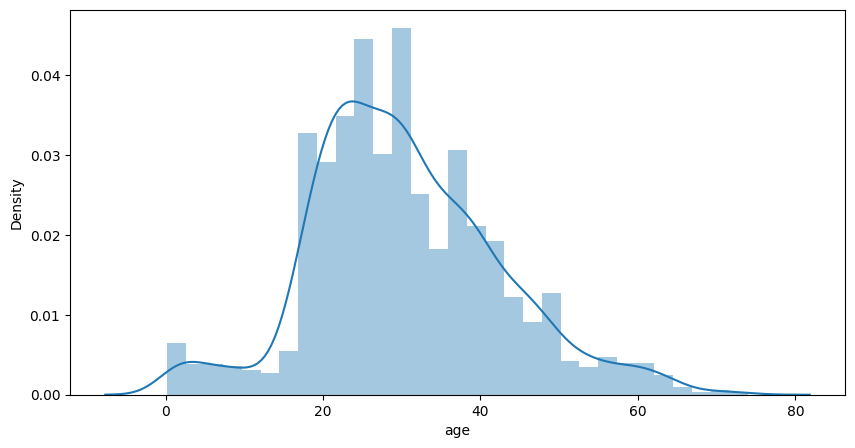

In [ ]:
full_data = pd.read_csv('titanic.csv')
sns.distplot(full_data['age'], hist=True)
plt.show()

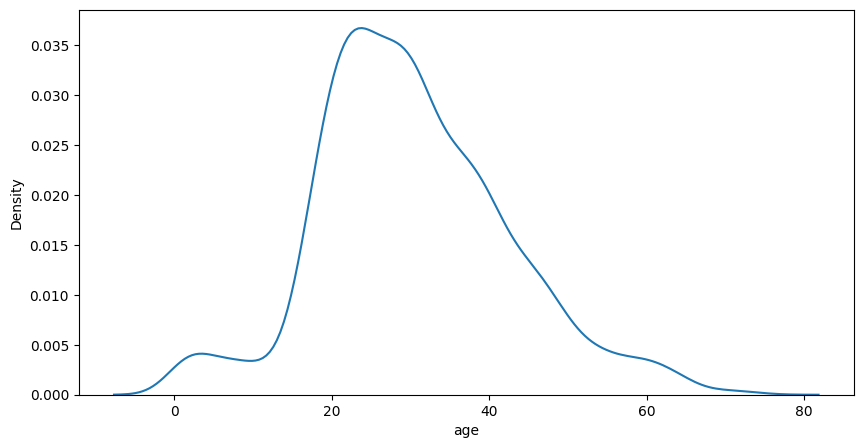

In [ ]:
sns.distplot(full_data['age'], hist=False)
plt.show()

In [ ]:
data.isnull().sum()

,0
name,0
gender,0
age,2
class,0
embarked,0
country,81
ticketno,891
fare,916
sibsp,900
parch,900


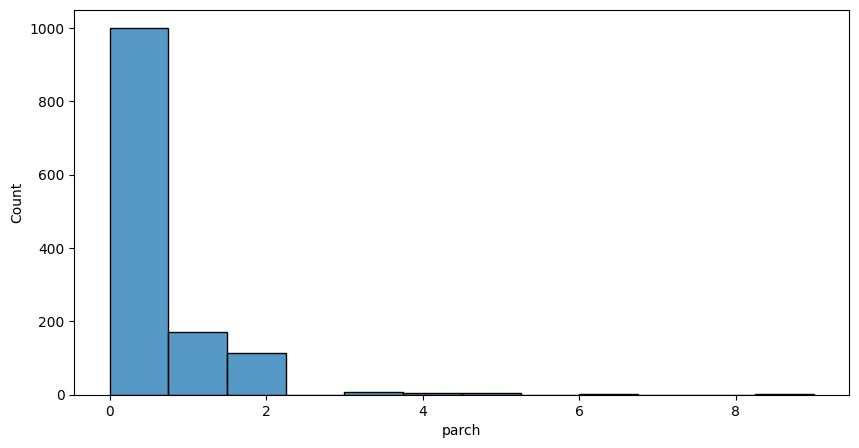

In [ ]:
sns.histplot(full_data['parch'], kde=False)
plt.show()

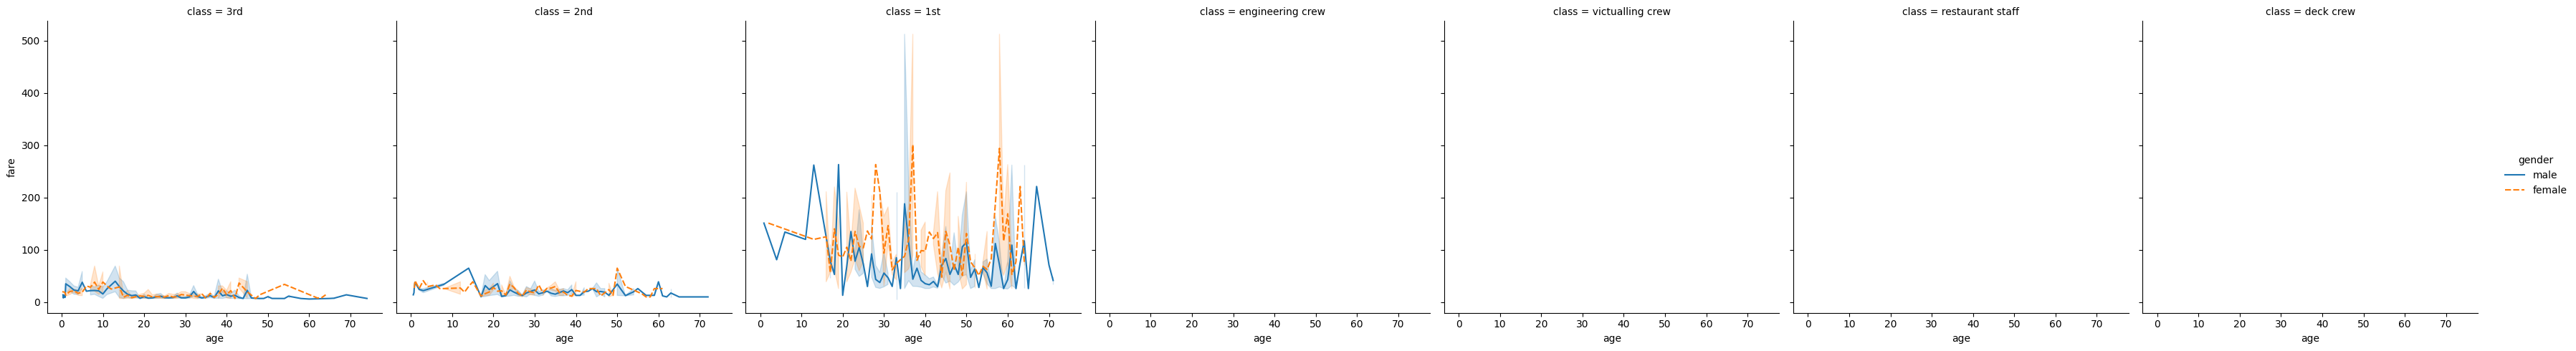

In [ ]:
sns.relplot(x='age', y='fare', col='class', hue='gender', style='gender', kind='line', data= full_data)
plt.show()

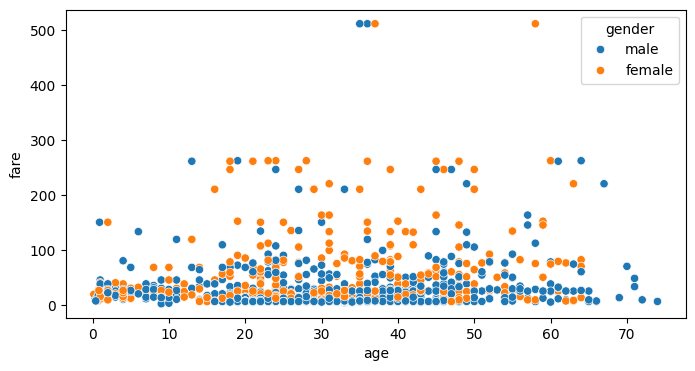

In [ ]:
plt.figure(figsize=[8,4])
sns.scatterplot(x='age', y='fare', hue='gender', data= full_data)
plt.show()

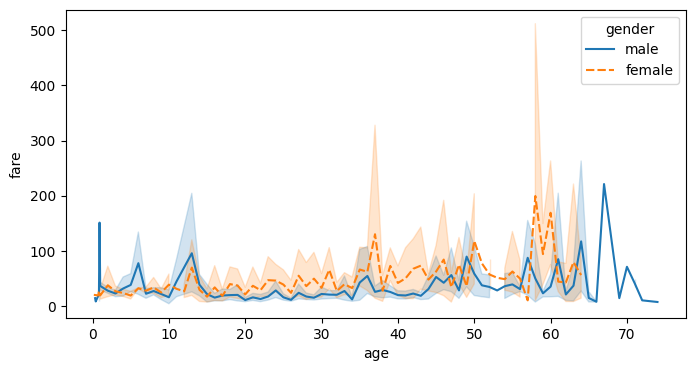

In [ ]:
plt.figure(figsize=[8,4])
sns.lineplot(x='age', y='fare', hue='gender', style='gender', data= full_data)
plt.show()

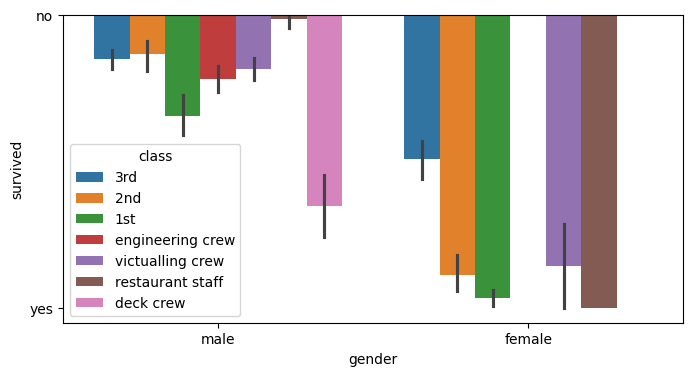

In [ ]:
plt.figure(figsize=[8,4])
sns.barplot(x='gender', y='survived', hue='class',  data = full_data)
plt.show()

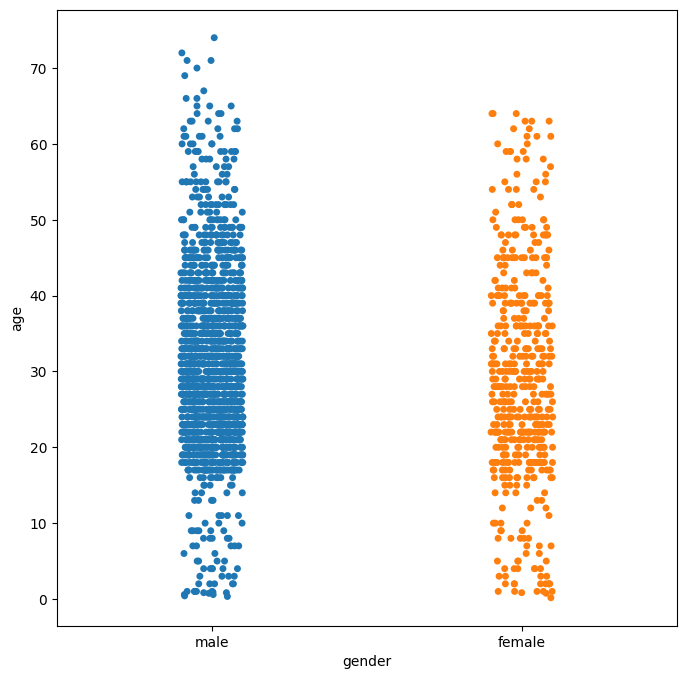

In [ ]:
plt.figure(figsize=[8,8])
sns.stripplot(x='gender', y='age', hue='gender', data= full_data)
plt.show()

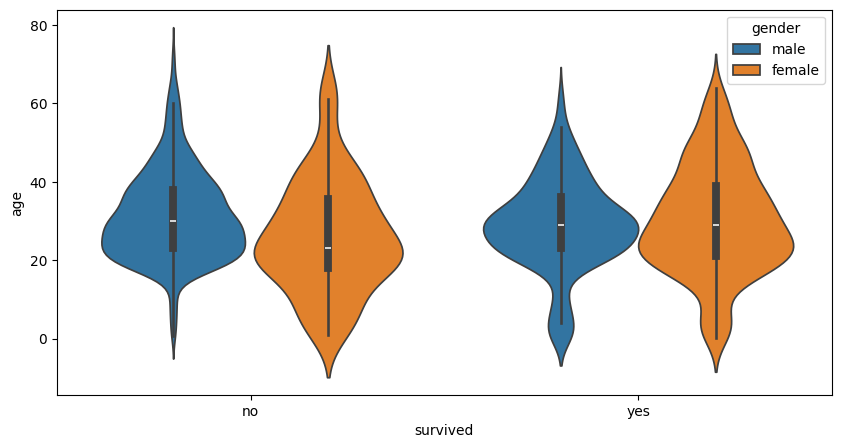

In [ ]:
sns.violinplot(x='survived', y='age', hue='gender', data= full_data)
plt.show()

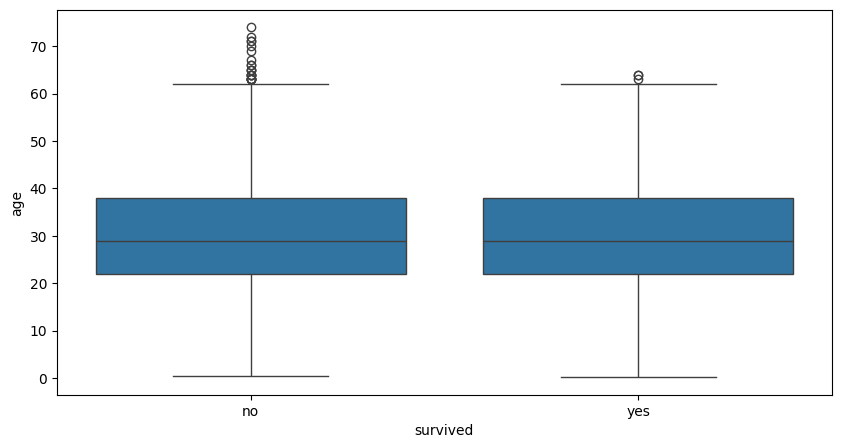

In [ ]:
sns.boxplot(x='survived', y='age', data= full_data)
plt.show()

In [ ]:
import pandas as pd
data = pd.read_csv('titanic.csv')

In [ ]:
data

,name,gender,age,class,embarked,country,ticketno,fare,sibsp,parch,survived
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0.0,0.0,no
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0.0,2.0,no
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,1.0,1.0,no
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1.0,1.0,yes
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,0.0,0.0,yes
...,...,...,...,...,...,...,...,...,...,...,...
2202,"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,NaN,NaN,yes
2203,"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,NaN,NaN,yes
2204,"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,NaN,NaN,no
2205,"Zanetti, Sig. Minio",male,20.0,restaurant staff,S,England,NaN,NaN,NaN,NaN,no


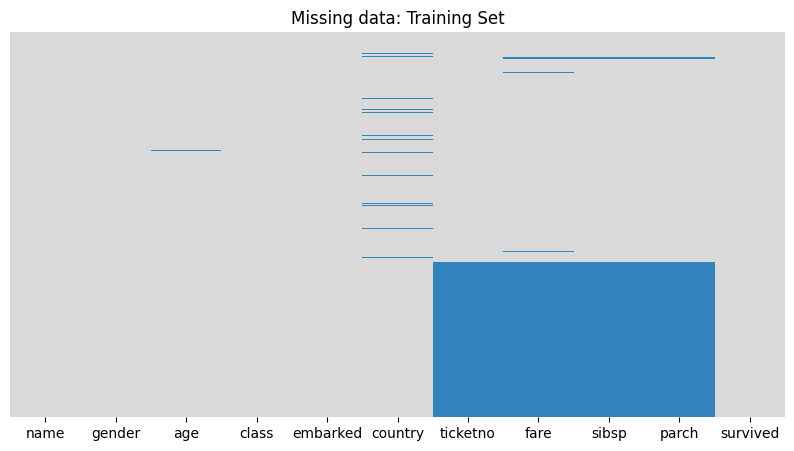

In [ ]:
sns.heatmap(full_data.isnull(), yticklabels= False, cbar=False, cmap= 'tab20c_r')
plt.title('Missing data: Training Set')
plt.show()

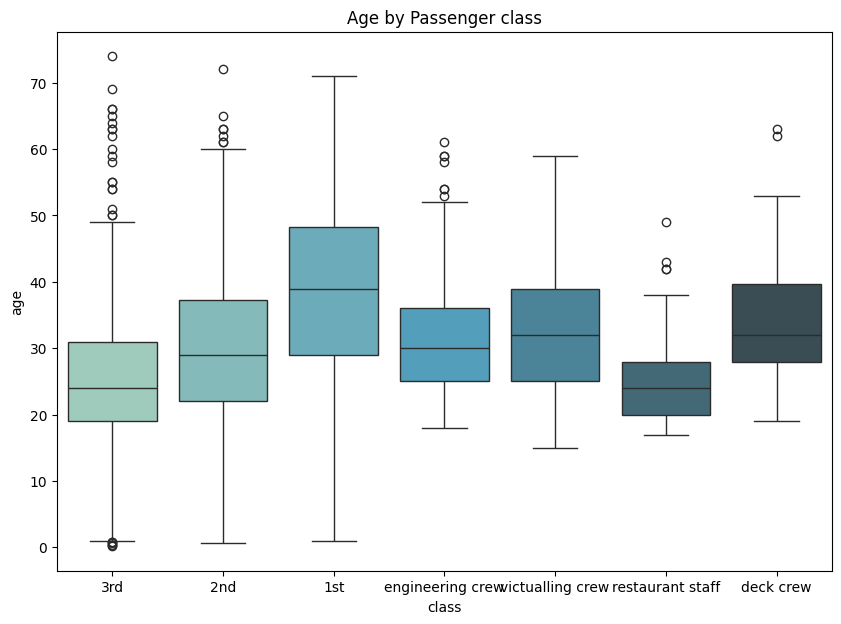

In [ ]:
plt.figure(figsize=[10,7])
sns.boxplot(x='class', y='age', data=full_data, palette='GnBu_d').set_title('Age by Passenger class')
plt.show()

In [ ]:
full_data = pd.read_csv('titanic.csv')

In [ ]:
full_data

,name,gender,age,class,embarked,country,ticketno,fare,sibsp,parch,survived
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0.0,0.0,no
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0.0,2.0,no
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,1.0,1.0,no
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1.0,1.0,yes
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,0.0,0.0,yes
...,...,...,...,...,...,...,...,...,...,...,...
2202,"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,NaN,NaN,yes
2203,"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,NaN,NaN,yes
2204,"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,NaN,NaN,no
2205,"Zanetti, Sig. Minio",male,20.0,restaurant staff,S,England,NaN,NaN,NaN,NaN,no


In [ ]:
# Imputation function
def impute_age(clos):
  age = clos[0]
  class = cols[1]

  if pd.isnull(age):
    if pclass == 1:
      return 37
    elif pclass == 2:
      return 29
    else:
      return 24
  else:
      return age

# Apply the function to the age column
  full_data['age'] = full_data[['age', 'class' ]].apply(impute_age, axis=1)

SyntaxError: invalid syntax (<ipython-input-50-b7f7592d8fd1>, line 4)

In [ ]:
full_data.dropna(inplace=True)

In [ ]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1213 entries, 0 to 1318
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      1213 non-null   object 
 1   gender    1213 non-null   object 
 2   age       1213 non-null   float64
 3   class     1213 non-null   object 
 4   embarked  1213 non-null   object 
 5   country   1213 non-null   object 
 6   ticketno  1213 non-null   float64
 7   fare      1213 non-null   float64
 8   sibsp     1213 non-null   float64
 9   parch     1213 non-null   float64
 10  survived  1213 non-null   object 
dtypes: float64(5), object(6)
memory usage: 113.7+ KB


In [ ]:
# Remove unnecesary columns
full_data.drop(['name', 'ticketno'], axis=1, inplace=True)

# convert objects to category data type
objcat = ['gender', 'embarked']

for colname in objcat:
  full_data[colname] = full_data[colname].astype('category')

KeyError: "['name', 'ticketno'] not found in axis"

In [ ]:
full_data.select_dtypes(['category']).columns

Index(['gender', 'embarked'], dtype='object')

In [ ]:
gender = pd.get_dummies(full_data['gender'], drop_first= True)
embarked = pd.get_dummies(full_data['embarked'], drop_first= True)

In [ ]:
full_data = pd.concat([full_data, gender, embarked], axis=1)
full_data.head(5)

,gender,age,class,embarked,country,fare,sibsp,parch,survived,male,Q,S
0,male,42.0,3rd,S,United States,7.11,0.0,0.0,no,True,False,True
1,male,13.0,3rd,S,United States,20.05,0.0,2.0,no,True,False,True
2,male,16.0,3rd,S,United States,20.05,1.0,1.0,no,True,False,True
3,female,39.0,3rd,S,England,20.05,1.0,1.0,yes,False,False,True
4,female,16.0,3rd,S,Norway,7.13,0.0,0.0,yes,False,False,True


In [ ]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1213 entries, 0 to 1318
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   gender    1213 non-null   category
 1   age       1213 non-null   float64 
 2   class     1213 non-null   object  
 3   embarked  1213 non-null   category
 4   country   1213 non-null   object  
 5   fare      1213 non-null   float64 
 6   sibsp     1213 non-null   float64 
 7   parch     1213 non-null   float64 
 8   survived  1213 non-null   object  
 9   male      1213 non-null   bool    
 10  Q         1213 non-null   bool    
 11  S         1213 non-null   bool    
dtypes: bool(3), category(2), float64(4), object(3)
memory usage: 82.0+ KB


In [ ]:
full_data['male'] = full_data['male'].astype(int)
full_data['Q'] = full_data['Q'].astype(int)
full_data['S'] = full_data['S'].astype(int)



In [ ]:
full_data.drop('gender', axis=1, inplace= True)
full_data.drop('embarked', axis=1, inplace= True)

full_data.drop('country', axis=1, inplace= True)

In [ ]:
full_data.head(5)

,age,class,fare,sibsp,parch,survived,male,Q,S
0,42.0,3rd,7.11,0.0,0.0,no,1,0,1
1,13.0,3rd,20.05,0.0,2.0,no,1,0,1
2,16.0,3rd,20.05,1.0,1.0,no,1,0,1
3,39.0,3rd,20.05,1.0,1.0,yes,0,0,1
4,16.0,3rd,7.13,0.0,0.0,yes,0,0,1


In [ ]:
full_data['survived'] = [0 if i == 'no' else  1 for i in full_data['survived'] ]
full_data['class'] = [1 if i == '1st' else 2 if i == '2nd' else 3 for i in full_data['class']]

In [ ]:
full_data['class'].unique()

array([3, 2, 1])

In [ ]:
x = full_data.drop('survived', axis=1)
y = full_data['survived']

In [ ]:
x

,age,class,fare,sibsp,parch,male,Q,S
0,42.0,3,7.1100,0.0,0.0,1,0,1
1,13.0,3,20.0500,0.0,2.0,1,0,1
2,16.0,3,20.0500,1.0,1.0,1,0,1
3,39.0,3,20.0500,1.0,1.0,0,0,1
4,16.0,3,7.1300,0.0,0.0,0,0,1
...,...,...,...,...,...,...,...,...
1314,24.0,2,13.0000,0.0,0.0,0,0,1
1315,22.0,3,7.0406,0.0,0.0,1,0,0
1316,27.0,3,7.0406,0.0,0.0,1,0,0
1317,25.0,3,7.0406,0.0,0.0,1,0,0


In [ ]:
full_data['class'].unique()

array([3, 2, 1])

In [ ]:
from sklearn import preprocessing
pre_process = preprocessing.StandardScaler().fit(x)
x_transform = pre_process.fit_transform(x)

In [ ]:
# Use x and y variables to split the training data into train and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.20, random_state=101)

In [ ]:
# Import model

from sklearn.linear_model import LogisticRegression
print('logistic Regression')

# Create instance of the model
log_reg = LogisticRegression()

# Pass training data into model
log_reg.fit(x_train, y_train)



logistic Regression


LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score
# Prediction from the model
y_pred_log_reg = log_reg.predict(x_test)

print('Logistic Regression')

# Accuracy
print('__'*30)
log_reg_accuracy = round(accuracy_score(y_test, y_pred_log_reg) * 100,2)
print('Accuracy', log_reg_accuracy, '%')

Logistic Regression
____________________________________________________________
Accuracy 80.25 %


In [ ]:
from sklearn.tree import DecisionTreeClassifier
print('Decision Tree Calssifier')
# Create instance of model
Dtree = DecisionTreeClassifier()

# Pass training daa into model
Dtree.fit(x_train, y_train)

Decision Tree Calssifier


DecisionTreeClassifier()

In [ ]:
from sklearn.metrics import accuracy_score
# Prediction from the model
y_pred_Dtree = Dtree.predict(x_test)

print('Decision Tree Classifier')

# Accuracy
print('__'*30)
Dtree_accuracy = round(accuracy_score(y_test, y_pred_Dtree) * 100,2)
print('Accuracy', Dtree_accuracy, '%')

Decision Tree Classifier
____________________________________________________________
Accuracy 72.84 %


In [ ]:
from sklearn.ensemble import RandomForestClassifier
print('Random Forest Calssifier')
# Create instance of model
rfc = RandomForestClassifier()

# Pass training daa into model
rfc.fit(x_train, y_train)

Random Forest Calssifier


RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score
print('Random Forest: ')
y_predict_rfc = rfc.predict(x_test)
print('__'* 30)
rfc_accuracy = round(accuracy_score(y_test, y_predict_rfc)* 100, 2)
print(f'Accuracy: {rfc_accuracy} %')

Random Forest: 
____________________________________________________________
Accuracy: 76.13 %


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
print('Gradient Boosting Classifier: ')

# Create instance of model
gbc = GradientBoostingClassifier()

# Pass training data into model
gbc.fit(x_train, y_train)


Gradient Boosting Classifier: 


GradientBoostingClassifier()

In [ ]:
from sklearn.metrics import accuracy_score
y_predict_gbc = gbc.predict(x_test)

gbc_accuracy = round(accuracy_score(y_test, y_predict_gbc)* 100, 2)
print('__'*30)
print(f'Accuracy: {gbc_accuracy} %')

____________________________________________________________
Accuracy: 80.25 %


In [ ]:
model_scores = {
    'Logistic Regression': log_reg_accuracy,
    'Decision Tree Classifier': Dtree_accuracy,
    'Random Forest Classifier': rfc_accuracy,
    'Gradient Boosting Classifer': gbc_accuracy
}

In [ ]:
sorted_scores = sorted(model_scores.items(), key=lambda x: x[1], reverse=True)

In [ ]:
sorted_scores

[('Logistic Regression', 80.25),
 ('Gradient Boosting Classifer', 80.25),
 ('Random Forest Classifier', 76.13),
 ('Decision Tree Classifier', 72.84)]

In [ ]:
# Display the ranking of the models
print('Model Rankings (Greater values are better): ')

for rank, (model_name, score) in enumerate(sorted_scores, start=1):
  print(f"{rank}. {model_name}: {score}: ")

Model Rankings (Greater values are better): 
1. Logistic Regression: 80.25: 
2. Gradient Boosting Classifer: 80.25: 
3. Random Forest Classifier: 76.13: 
4. Decision Tree Classifier: 72.84: 


In [ ]:
# Display the ranking of the models
print('Model Rankings (Greater values are better): ')

for rank, (model_name, score) in enumerate(sorted_scores, start=1):
  print(f"{rank}. {model_name}: {score}")

Model Rankings (Greater values are better): 
1. Logistic Regression: 80.25
2. Gradient Boosting Classifer: 80.25
3. Random Forest Classifier: 76.13
4. Decision Tree Classifier: 72.84


# **After this we are starting regression. We are using usa_housing.csv file for our practice.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [7,5]
warnings.simplefilter(action='ignore', category= FutureWarning)

In [ ]:
full_data = pd.read_csv('USA_Housing.csv')

In [ ]:
print(f'Train Data: {full_data.shape}')

Train Data: (5000, 7)


In [ ]:
full_data.head(5)

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [ ]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


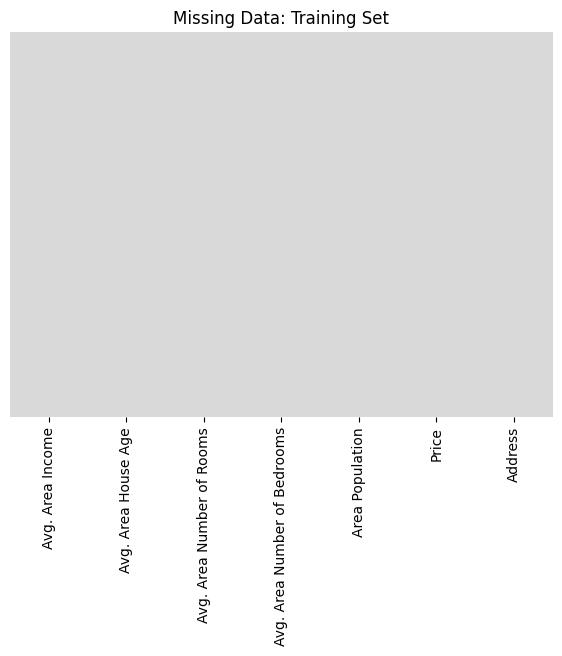

In [ ]:
# Finding missing data
sns.heatmap(full_data.isnull(), yticklabels=False, cbar=False, cmap='tab20c_r')
plt.title('Missing Data: Training Set')
plt.show()


In [ ]:
# Drop Adress column
full_data.drop('Address', axis=1, inplace=True)

In [ ]:
# Finding the number of null Values
full_data.isnull().sum()

,0
Avg. Area Income,0
Avg. Area House Age,0
Avg. Area Number of Rooms,0
Avg. Area Number of Bedrooms,0
Area Population,0
Price,0


In [ ]:
# If Null Values exist we can drop rows which have null values
full_data.dropna(inplace=True)

In [ ]:
full_data

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05
...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06


In [ ]:
full_data.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [ ]:
# Create matrix of Features
x = full_data.drop('Price', axis=1)

# Create Target variable
y = full_data['Price']

In [ ]:
from sklearn import preprocessing
pre_process = preprocessing.StandardScaler().fit(x)
x_transform = pre_process.fit_transform(x)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_transform,y, test_size=0.1, random_state = 101 )

In [ ]:
# Fiting MOdel
# Importing model
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Creating instance of the model
lin_reg = LinearRegression()

# Passing Training data
lin_reg.fit(x_train, y_train)

# Pipe = make_pipeline(StandardScaler(), LinearRegression)
# pipe.fit(x_train, y_train)

# Prediction
y_pred = lin_reg.predict(x_test)

InvalidParameterError: The 'y_true' parameter of mean_squared_error must be an array-like. Got 809121.1058431822 instead.

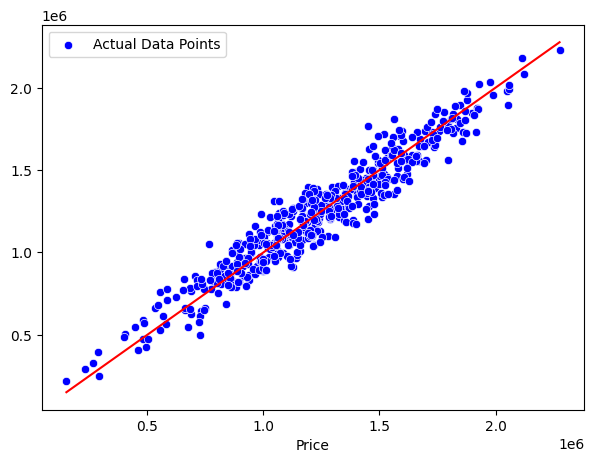

In [ ]:
# Scatter plotting
sns.scatterplot(x= y_test, y= y_pred, color='blue', label = 'Actual Data Points')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label= 'Ideal Line')
plt.show()

In [ ]:
# Combined Actual and predicted values side by side
results = np.column_stack((y_test, y_pred))
for actual, predicted in results:
  print(f"{actual: 14.2f} | {predicted:12.2f}")

    1251688.62 |   1257098.10
     873048.32 |    822086.76
    1696977.66 |   1739484.60
    1063964.29 |    973128.93
     948788.28 |    993918.46
     730043.65 |    645734.60
    1166925.15 |   1074412.82
     705444.12 |    856463.98
    1499988.88 |   1445048.63
    1288199.15 |   1201847.72
    1441736.76 |   1454475.52
    1279681.15 |   1296582.99
    1754969.16 |   1736858.05
    1511653.45 |   1336694.59
    1441956.20 |   1386280.01
    1119992.62 |   1223122.35
     727866.53 |    615840.79
    1138885.10 |    964515.62
    1074263.32 |   1222020.64
    1386473.37 |   1197532.32
     404643.60 |    506756.97
    1449829.49 |   1767894.37
    1775874.76 |   1854829.43
    1202050.58 |   1198521.38
    1105737.46 |   1065384.60
    1835564.69 |   1810199.63
    1795428.77 |   1767830.26
    1424283.37 |   1440162.97
    1365945.08 |   1386122.52
    1492011.50 |   1539972.95
     624432.97 |    729561.93
    1827476.20 |   1754434.69
    1575680.04 |   1465273.07
    105151

In [ ]:
# Finding the accuracy of Regressioin model
residual = actual - y_pred.reshape(-1)
print(residual)

[-4.47976991e+05 -1.29656563e+04 -9.30363496e+05 -1.64007821e+05
 -1.84797352e+05  1.63386505e+05 -2.65291711e+05 -4.73428778e+04
 -6.35927528e+05 -3.92726613e+05 -6.45354412e+05 -4.87461883e+05
 -9.27736939e+05 -5.27573484e+05 -5.77158901e+05 -4.14001244e+05
  1.93280320e+05 -1.55394518e+05 -4.12899532e+05 -3.88411212e+05
  3.02364139e+05 -9.58773265e+05 -1.04570832e+06 -3.89400269e+05
 -2.56263495e+05 -1.00107852e+06 -9.58709156e+05 -6.31041869e+05
 -5.77001411e+05 -7.30851843e+05  7.95591739e+04 -9.45313588e+05
 -6.56151968e+05 -2.16900693e+05 -4.74393474e+05 -1.08567223e+05
 -3.76559930e+05 -1.91016790e+05 -5.20223693e+05  2.48588063e+04
 -5.83407371e+05  2.32551803e+05 -1.43440386e+04 -1.08477413e+06
 -8.62444634e+05 -1.55598956e+05 -3.20159803e+05  1.65461371e+04
 -3.50260334e+05 -6.64088141e+05 -6.50406212e+05 -3.55371754e+05
 -2.89631885e+05 -5.51037037e+05 -3.40729888e+04 -1.76177411e+05
 -3.14410480e+05 -4.43290991e+05 -6.17494513e+05  3.09119767e+05
 -6.52248349e+05 -2.97038

<Axes: ylabel='Density'>

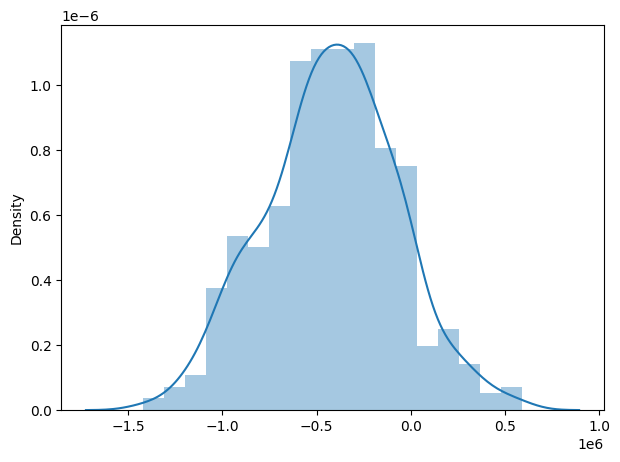

In [ ]:
# Distribution plot for residual
sns.distplot(residual, kde=True)

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
print('Random Forest Regressor')
# Create instance of model
rf_regressor = RandomForestRegressor()
rf_regressor.fit(x_train, y_train)
# Predicting the salePrices using test set
y_pred_rf = rf_regressor.predict(x_test)

RFr_mse = mean_squared_error(y_pred_rf, y_test)
rmse = np.sqrt(RFr_mse)

# Random Forest Regression Accuracy with test set
print(f" Random Forest Regression MSE: {RFr_mse}")
print(f" Random Forest Regression RMSE: {rmse}")

Random Forest Regressor
 Random Forest Regression MSE: 14239399730.374678
 Random Forest Regression RMSE: 119328.95595945972


In [ ]:
from sklearn.tree import DecisionTreeRegressor
print('Decision Tree Regressor')
# Create instance of model
dt_regressor = DecisionTreeRegressor()
dt_regressor.fit(x_train, y_train)
# Predicting the salePrices using test set
y_pred_dt = dt_regressor.predict(x_test)

DTr_mse = mean_squared_error(y_pred_dt, y_test)
rmse = np.sqrt(DTr_mse)

# Decision Tree Regressor Accuracy with test set
print(f"Decision Tree Regressor MSE: {DTr_mse}")
print(f"Decision Tree Regressor RMSE: {rmse}")


Decision Tree Regressor
Decision Tree Regressor MSE: 31945953751.76824
Decision Tree Regressor RMSE: 178734.31050519718


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
print('Gradient Boosting Regressor')
# Create instance of model
GB_regressor = DecisionTreeRegressor()
GB_regressor.fit(x_train, y_train)
# Predicting the salePrices using test set
y_pred_gb = GB_regressor.predict(x_test)

GBr_mse = mean_squared_error(y_pred_gb, y_test)
rmse = np.sqrt(GBr_mse)
# Random Forest Regression Accuracy with test set
print(f"Gradient Boosting Regressor MSE: {GBr_mse}")
print(f"Gradient Boosting Regressor RMSE: {rmse}")

Gradient Boosting Regressor
Gradient Boosting Regressor MSE: 31199072822.647034
Gradient Boosting Regressor RMSE: 176632.59275299968
